Используя базу "Пассажиры автобуса", подготовьте данные для обучения нейронной сети, классифицирующей изображение на два класса:
- входящий пассажир
- выходящий пассажир

Добейтесь точности работы модели на проверочной выборке не ниже 85%

Ссылка на датасет: https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip

Информацию о загрузке изображений и преобразовании их в numnpy-массивы вы можете найти в Базе знаний:


## Подключение библиотек и загрузка данных

In [25]:
# Работа с массивами
import numpy as np
import os
import zipfile

# Работа с изображениями
from PIL import Image

# Визуализация
import matplotlib.pyplot as plt

# TensorFlow и Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Для разделения данных на выборки
from sklearn.model_selection import train_test_split

# Отображение графиков прямо в ноутбуке
%matplotlib inline

# Пути к архиву и папке для распаковки
zip_path = "bus.zip"
extract_path = "bus_data"

# Распаковка архива
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Распаковка завершена. Каталог:", os.listdir(extract_path))

Распаковка завершена. Каталог: ['Входящий', 'Выходящий']


## Предобработка и подготовка данных

In [26]:
# Определяем классы
classes = ["Входящий", "Выходящий"]

# Списки для хранения изображений и меток
images = []
labels = []

# Преобразуем все изображения в numpy массивы
for label, cls in enumerate(classes):
    cls_folder = os.path.join(extract_path, cls)
    for file_name in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, file_name)
        try:
            img = Image.open(img_path).convert("L")  # grayscale
            img = img.resize((28,28))                # приведение к размеру 28x28
            images.append(np.array(img))
            labels.append(label)
        except:
            pass

# Преобразуем списки в numpy массивы
X = np.array(images, dtype="float32") / 255.0  # нормализация
y = to_categorical(np.array(labels), num_classes=2)

# Разделение на обучающую, проверочную и тестовую выборки
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42, shuffle=True)

print("Форма X_train:", X_train.shape)
print("Форма y_train:", y_train.shape)
print("Форма X_val:", X_val.shape)
print("Форма y_val:", y_val.shape)
print("Форма X_test:", X_test.shape)
print("Форма y_test:", y_test.shape)

Форма X_train: (7354, 28, 28)
Форма y_train: (7354, 2)
Форма X_val: (818, 28, 28)
Форма y_val: (818, 2)
Форма X_test: (909, 28, 28)
Форма y_test: (909, 2)


## Визуализация

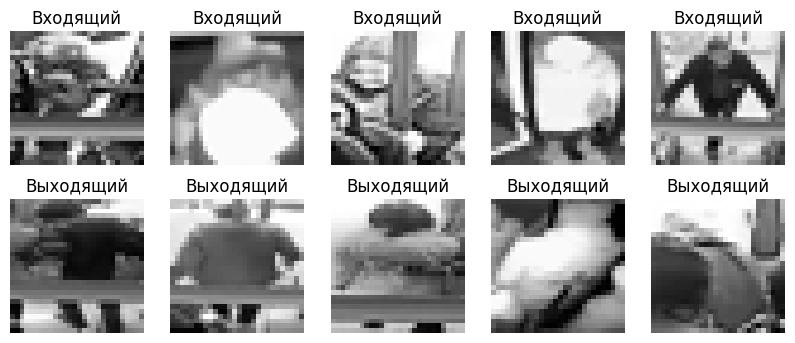

In [27]:
# Показываем по 5 изображений из каждого класса
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[y_train[:,0]==1][i], cmap="gray")
    plt.axis("off")
    plt.title("Входящий")

    plt.subplot(2,5,i+6)
    plt.imshow(X_train[y_train[:,1]==1][i], cmap="gray")
    plt.axis("off")
    plt.title("Выходящий")
plt.show()

## Создание модели

In [28]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))   # преобразуем 2D в 1D
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [29]:
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    verbose=1)

Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7052 - loss: 0.5974 - val_accuracy: 0.7237 - val_loss: 0.5520
Epoch 2/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7172 - loss: 0.5644 - val_accuracy: 0.7298 - val_loss: 0.5393
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7344 - loss: 0.5423 - val_accuracy: 0.7457 - val_loss: 0.5160
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7420 - loss: 0.5307 - val_accuracy: 0.7689 - val_loss: 0.4906
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7454 - loss: 0.5152 - val_accuracy: 0.7800 - val_loss: 0.4937
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7493 - loss: 0.5028 - val_accuracy: 0.7836 - val_loss: 0.4502
Epoch 7/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7551 - loss: 0.4854 - val_accuracy: 0.7641 - val_loss: 0.4639
Epoch 8/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7627 - loss: 0.4772 - val_accuracy: 0

## Визуализация точности и ошибки

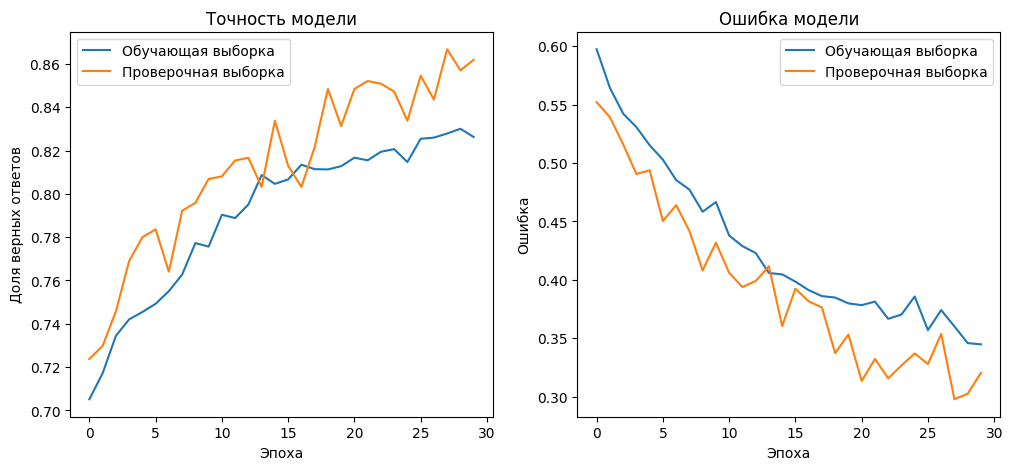

In [30]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Обучающая выборка")
plt.plot(history.history['val_accuracy'], label="Проверочная выборка")
plt.xlabel("Эпоха")
plt.ylabel("Доля верных ответов")
plt.title("Точность модели")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Обучающая выборка")
plt.plot(history.history['val_loss'], label="Проверочная выборка")
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Ошибка модели")
plt.legend()

plt.show()

## Оценка модели на тестовой выборке

In [31]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("Доля верных ответов на тестовых данных: {:7.4%}".format(scores[1]))

Доля верных ответов на тестовых данных: 86.0286%
